In [14]:
from scipy.signal import sosfreqz
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import butter
from scipy.signal import sosfilt

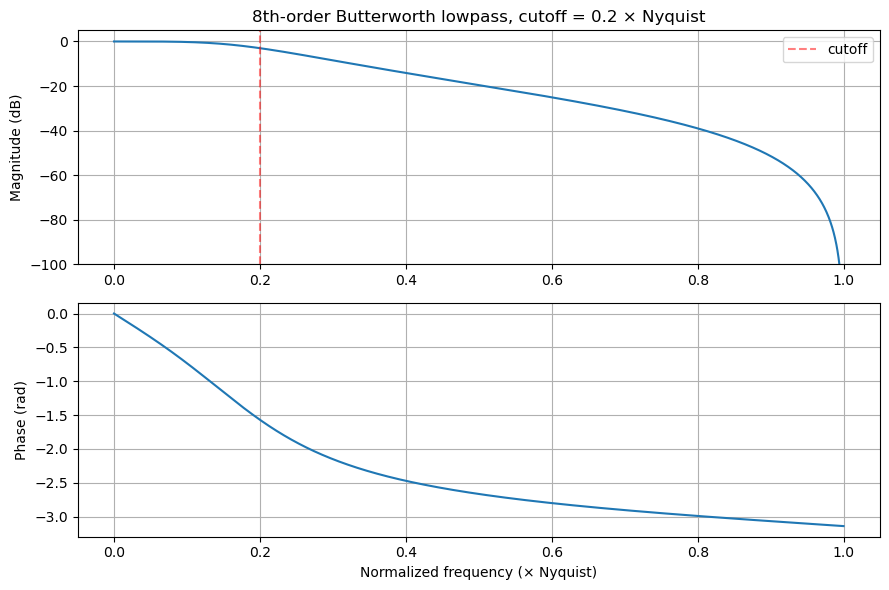

In [15]:
sos2 = butter(N=2, Wn=0.2, btype='lowpass', output='sos')

# Compute frequency response
w, h = sosfreqz(sos2, worN=2048, fs=2)   # fs=2 gives normalized freq 0..1

# Plot magnitude in dB and phase
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6))

ax1.plot(w, 20 * np.log10(np.abs(h) + 1e-12))
ax1.set_ylabel('Magnitude (dB)')
ax1.set_title('8th-order Butterworth lowpass, cutoff = 0.2 × Nyquist')
ax1.grid(True)
ax1.set_ylim(-100, 5)
ax1.axvline(0.2, color='r', linestyle='--', alpha=0.5, label='cutoff')
ax1.legend()

ax2.plot(w, np.unwrap(np.angle(h)))
ax2.set_ylabel('Phase (rad)')
ax2.set_xlabel('Normalized frequency (× Nyquist)')
ax2.grid(True)

plt.tight_layout()
plt.show()

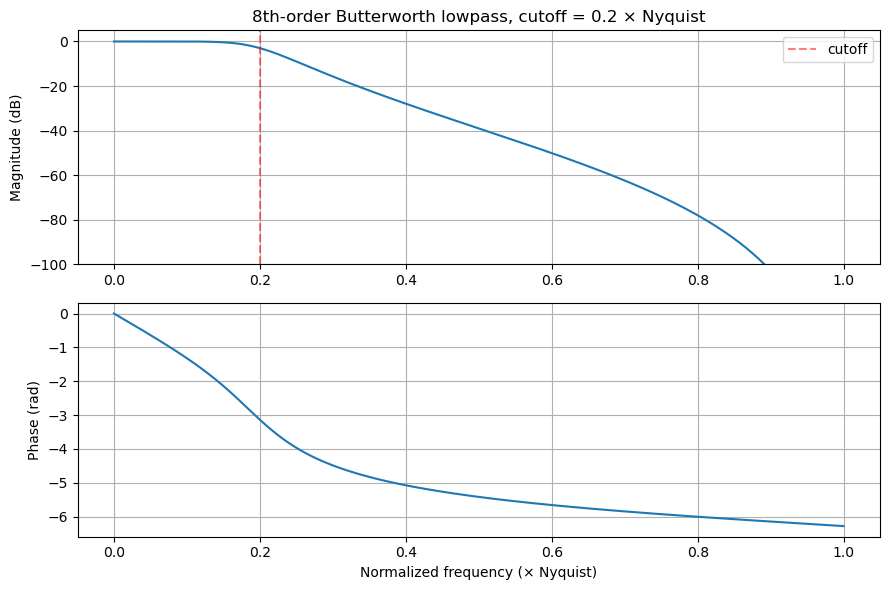

In [16]:
sos4 = butter(N=4, Wn=0.2, btype='lowpass', output='sos')

# Compute frequency response
w, h = sosfreqz(sos4, worN=2048, fs=2)   # fs=2 gives normalized freq 0..1

# Plot magnitude in dB and phase
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6))

ax1.plot(w, 20 * np.log10(np.abs(h) + 1e-12))
ax1.set_ylabel('Magnitude (dB)')
ax1.set_title('8th-order Butterworth lowpass, cutoff = 0.2 × Nyquist')
ax1.grid(True)
ax1.set_ylim(-100, 5)
ax1.axvline(0.2, color='r', linestyle='--', alpha=0.5, label='cutoff')
ax1.legend()

ax2.plot(w, np.unwrap(np.angle(h)))
ax2.set_ylabel('Phase (rad)')
ax2.set_xlabel('Normalized frequency (× Nyquist)')
ax2.grid(True)

plt.tight_layout()
plt.show()

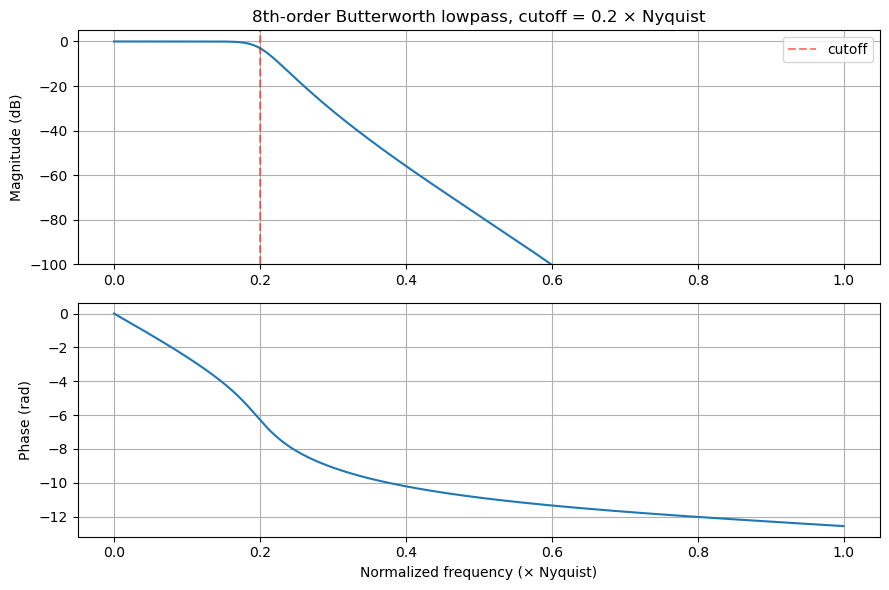

In [17]:
sos8 = butter(N=8, Wn=0.2, btype='lowpass', output='sos')

# Compute frequency response
w, h = sosfreqz(sos8, worN=2048, fs=2)   # fs=2 gives normalized freq 0..1

# Plot magnitude in dB and phase
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6))

ax1.plot(w, 20 * np.log10(np.abs(h) + 1e-12))
ax1.set_ylabel('Magnitude (dB)')
ax1.set_title('8th-order Butterworth lowpass, cutoff = 0.2 × Nyquist')
ax1.grid(True)
ax1.set_ylim(-100, 5)
ax1.axvline(0.2, color='r', linestyle='--', alpha=0.5, label='cutoff')
ax1.legend()

ax2.plot(w, np.unwrap(np.angle(h)))
ax2.set_ylabel('Phase (rad)')
ax2.set_xlabel('Normalized frequency (× Nyquist)')
ax2.grid(True)

plt.tight_layout()
plt.show()

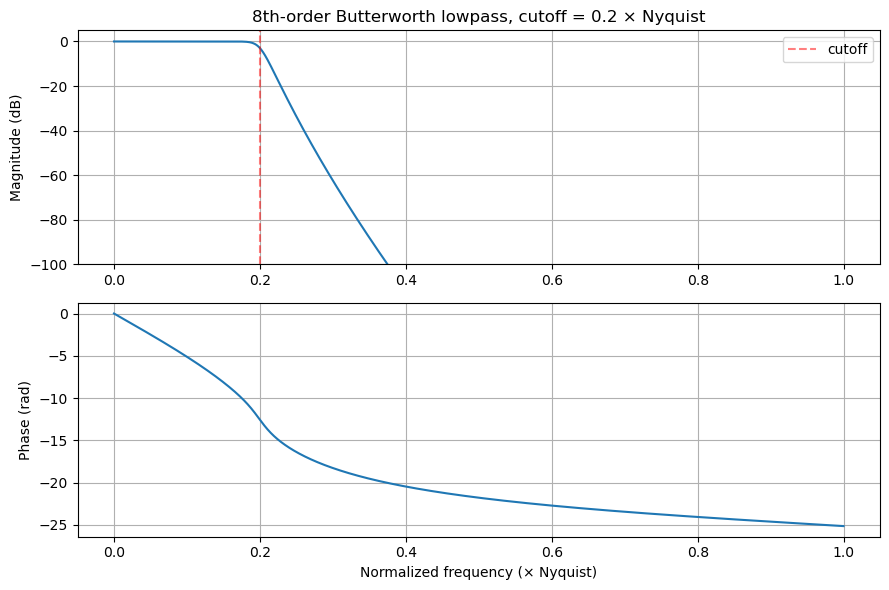

In [18]:
sos16 = butter(N=16, Wn=0.2, btype='lowpass', output='sos')

# Compute frequency response
w, h = sosfreqz(sos16, worN=2048, fs=2)   # fs=2 gives normalized freq 0..1

# Plot magnitude in dB and phase
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6))

ax1.plot(w, 20 * np.log10(np.abs(h) + 1e-12))
ax1.set_ylabel('Magnitude (dB)')
ax1.set_title('8th-order Butterworth lowpass, cutoff = 0.2 × Nyquist')
ax1.grid(True)
ax1.set_ylim(-100, 5)
ax1.axvline(0.2, color='r', linestyle='--', alpha=0.5, label='cutoff')
ax1.legend()

ax2.plot(w, np.unwrap(np.angle(h)))
ax2.set_ylabel('Phase (rad)')
ax2.set_xlabel('Normalized frequency (× Nyquist)')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [19]:
def iir_2nd(x,sos,init):

    b1 = sos[1]/sos[0]
    b2 = sos[2]/sos[0]
    a1 = -sos[4]
    a2 = -sos[5]    
    xi1 = init[0]
    xi2 = init[1]
    yi1 = init[2]
    yi2 = init[3]
    y = np.zeros_like(x,dtype=float)
    for n in range(len(x)):
        if n == 0:
            y[0] = x[0] + b1*xi1 + b2*xi2 + a1*yi1 + a2* yi2
        elif n == 1:
            y[1] = x[1] + b1*x[0] + b2*xi1 + a1*y[0] + a2*yi1
        else:
            y[n] = x[n] + b1*x[n-1] + b2*x[n-2] + a1*y[n-1] + a2*y[n-2]

    return y

In [20]:
init = [0,0,0,0]

In [21]:
fs = 1000          # sample rate in Hz, cutoff frequency: 500*0.2
N_samples = 2**8   # number of samples
f_cosine = 120      # cosine frequency in Hz

t = np.arange(N_samples) / fs
x = np.cos(2 * np.pi * f_cosine * t)

In [22]:
def iir_cascade(x, sos, init):
    y = x * sos[0][0]                    # absorb first b0
    for i in range(len(sos)):
        y = iir_2nd(y, sos[i], init)
    return y

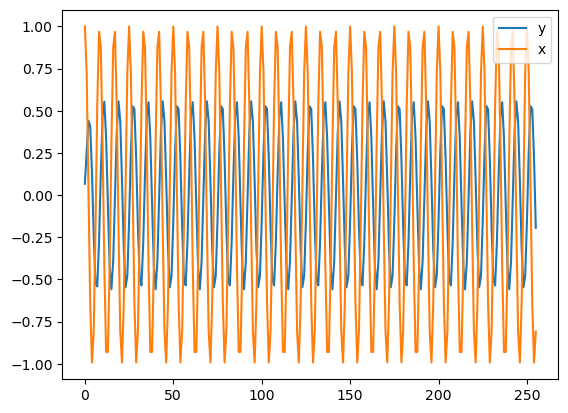

True

In [23]:
y_2 = iir_cascade(x,sos2,init)

plt.plot(y_2,label='y')
plt.plot(x,label='x')
plt.legend()
plt.show()

y_check = sosfilt(sos2, x)   # scipy's reference implementation
np.allclose(y_check, y_2, atol=1e-6)   # skip transient

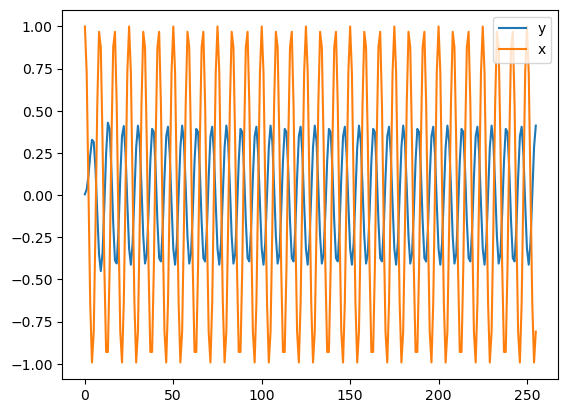

True

In [24]:
y_4 = iir_cascade(x,sos4,init)

plt.plot(y_4,label='y')
plt.plot(x,label='x')
plt.legend()
plt.show()

y_check = sosfilt(sos4, x)   # scipy's reference implementation
np.allclose(y_check, y_4, atol=1e-6)   # skip transient

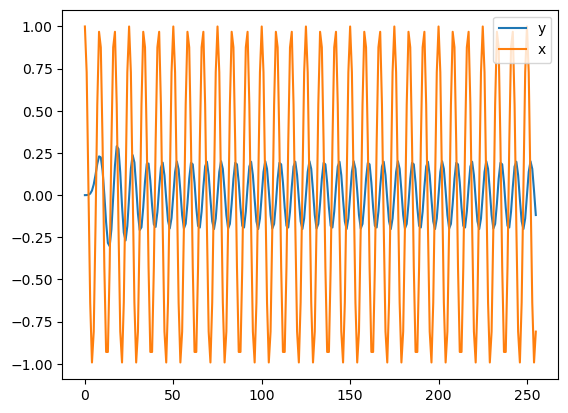

True

In [25]:
y_8 = iir_cascade(x,sos8,init)

plt.plot(y_8,label='y')
plt.plot(x,label='x')
plt.legend()
plt.show()

y_check = sosfilt(sos8, x)   # scipy's reference implementation
np.allclose(y_check, y_8, atol=1e-6)   # skip transient

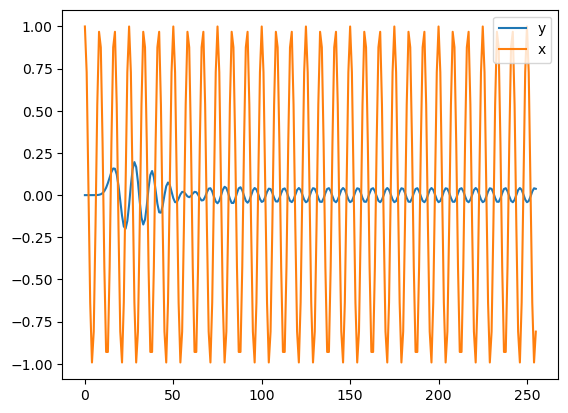

True

In [26]:
y_16 = iir_cascade(x,sos16,init)

plt.plot(y_16,label='y')
plt.plot(x,label='x')
plt.legend()
plt.show()

y_check = sosfilt(sos16, x)   # scipy's reference implementation
np.allclose(y_check, y_16, atol=1e-6)   # skip transient